# generating classfication dataset for anomaly detection

In [1]:
from sklearn.datasets import make_blobs
from matplotlib.pylab import plt

X, Y = make_blobs(n_samples=[950, 50], n_features=6, cluster_std=1.5, center_box=(-5.0, 5.0), random_state=24)

print(X.shape)
print(Y.shape)

(1000, 6)
(1000,)


In [2]:
print(f"number of samples with label 0: {len(Y[Y == 0])}")
print(f"number of samples with label 1: {len(Y[Y == 1])}")

number of samples with label 0: 950
number of samples with label 1: 50


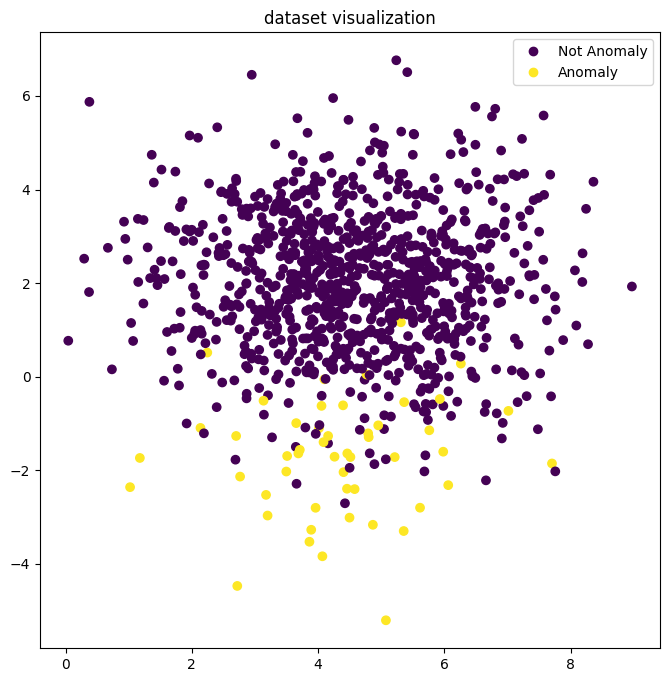

In [3]:
plt.figure(figsize=(8, 8))
plt.title("dataset visualization")
handles, _= plt.scatter(X[:, 0], X[:, 1], c=Y).legend_elements()
plt.legend(handles, ['Not Anomaly', 'Anomaly'])

# dataset preprocessing

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=24)

print("train set information")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"number of samples with label 0: {len(Y_train[Y_train == 0])}")
print(f"number of samples with label 1: {len(Y_train[Y_train == 1])}")
print()
print("test set information")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")
print(f"number of samples with label 0: {len(Y_test[Y_test == 0])}")
print(f"number of samples with label 1: {len(Y_test[Y_test == 1])}")

train set information
X_train shape: (800, 6)
Y_train shape: (800,)
number of samples with label 0: 761
number of samples with label 1: 39

test set information
X_test shape: (200, 6)
Y_test shape: (200,)
number of samples with label 0: 189
number of samples with label 1: 11


In [5]:
from sklearn.preprocessing import StandardScaler
import pickle


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X=X_train)

with open("scaler.pkl", 'wb') as file:
    pickle.dump(scaler, file=file)
    
print("fitted scaler saved as scaler.pkl")

fitted scaler saved as scaler.pkl


# training isolation forest model

In [6]:
from sklearn.ensemble import IsolationForest
import pickle

iso_forest = IsolationForest(contamination=0.05, random_state=24)
iso_forest.fit(X=x_train_scaled)

with open("iso_forest.pkl", 'wb') as file:
    pickle.dump(iso_forest, file=file)
    
print("fitted isolation forest saved as ios_forest.pkl")

iso_forest

fitted isolation forest saved as ios_forest.pkl


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",24
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


# loading fitted model and scaler

In [7]:
import pickle

with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file=file)
    
print("fitted scaler loaded from scaler.pkl")

with open("iso_forest.pkl", 'rb') as file:
    iso_forest = pickle.load(file=file)

print("fitted Isolation Forest loaded from iso_forest.pkl")

fitted scaler loaded from scaler.pkl
fitted Isolation Forest loaded from iso_forest.pkl


# making predictions and evaluation fitted model

In [8]:
x_test_scaled = scaler.transform(X_test)

y_pred = iso_forest.predict(x_test_scaled)

y_pred = [1 if x == -1 else 0 for x in y_pred]

print(y_pred)

[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true=Y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       189
           1       0.89      0.73      0.80        11

    accuracy                           0.98       200
   macro avg       0.94      0.86      0.89       200
weighted avg       0.98      0.98      0.98       200



Text(20.72222222222222, 0.5, 'original')

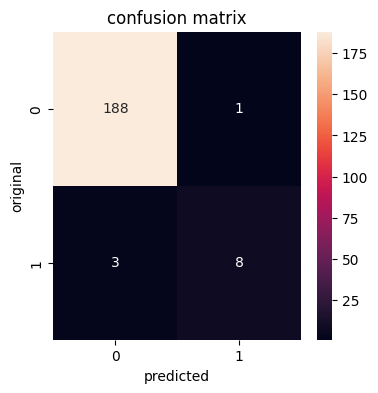

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(4, 4))
sns.heatmap(confusion_matrix(y_true=Y_test, y_pred=y_pred), annot=True, fmt='d')
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("original")

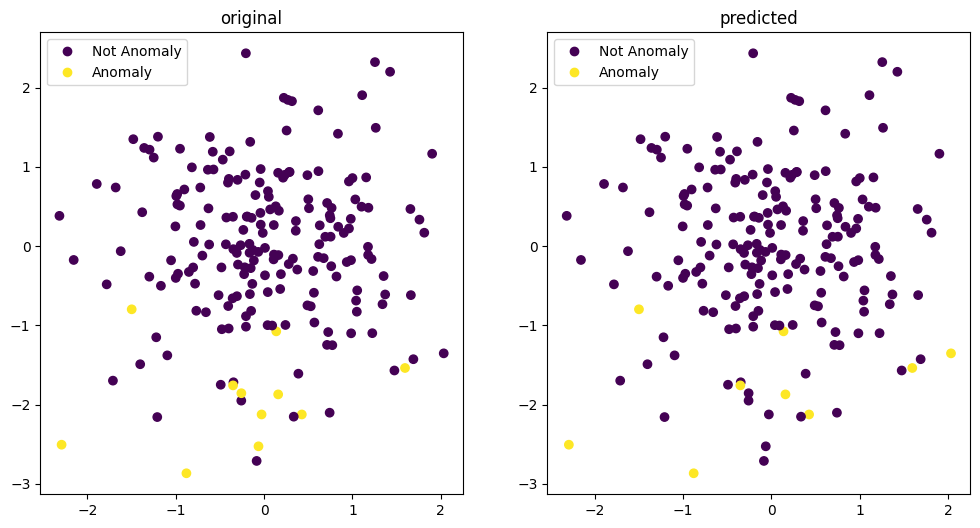

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

handle, _ = axs[0].scatter(x_test_scaled[:, 0], x_test_scaled[:, 1], c=Y_test).legend_elements()
axs[0].set_title('original')
axs[0].legend(handle, ['Not Anomaly', 'Anomaly'])

handle, _ = axs[1].scatter(x_test_scaled[:, 0], x_test_scaled[:, 1], c=y_pred).legend_elements()
axs[1].set_title('predicted')
axs[1].legend(handle, ['Not Anomaly', 'Anomaly'])

# plotting anomaly scores

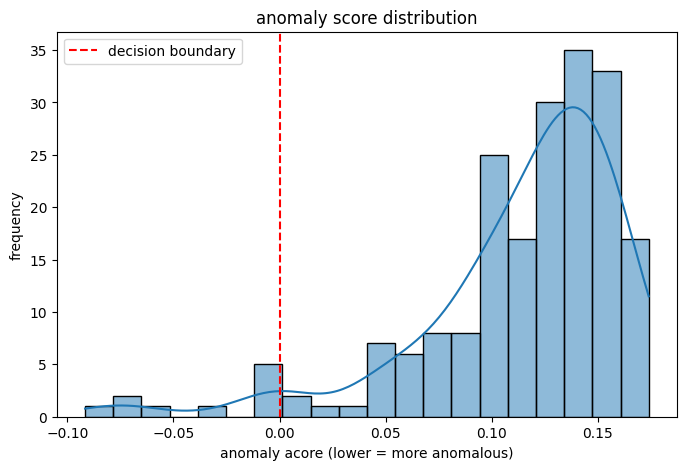

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

anomaly_scores = iso_forest.decision_function(x_test_scaled)

plt.figure(figsize=(8, 5))
sns.histplot(anomaly_scores, kde=True, bins=20)
plt.title("anomaly score distribution")
plt.xlabel("anomaly acore (lower = more anomalous)")
plt.ylabel("frequency")
plt.axvline(x=0, color='red', linestyle='--', label='decision boundary')
plt.legend()
plt.show()

## Results Summary – Isolation Forest Anomaly Detection

The Isolation Forest model was evaluated on the synthetic sensor dataset to detect anomalous behavior. The following key results were observed:

### Confusion Matrix Overview
- **True Negatives (Normal correctly classified):** 188  
- **False Positives (Normal misclassified as anomaly):** 1  
- **False Negatives (Anomaly missed):** 3  
- **True Positives (Anomaly correctly detected):** 8  

### Classification Performance
- **Accuracy:** 98%  
- **Precision (Anomaly class):** 0.89  
- **Recall (Anomaly class):** 0.73  
- **F1-Score (Anomaly class):** 0.80  

### Key Observations
- The model performs **exceptionally well on normal data detection (class 0)** with near-perfect precision and recall.
- For the **anomaly class (class 1)**, the model achieves **good precision (0.89)**, meaning most predicted anomalies are correct.
- However, **recall is relatively lower (0.73)**, indicating that some anomalies are still being missed (3 false negatives).
- The anomaly score distribution shows a **clear separation between normal and anomalous samples**, but with slight overlap near the decision boundary, which explains the missed detections.

### Conclusion
Overall, the Isolation Forest model is highly effective for this dataset, achieving strong accuracy and reliable anomaly identification. However, slight tuning of the contamination threshold or decision boundary could further improve anomaly recall and reduce missed detections.